In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
data_dir = "/home/bbc8731/NetMedGPT/reproduce_plots/results/"


In [3]:
# read TxGNN and its baseline results
txgnn_results = pd.read_csv(os.path.join(data_dir, "result_more_metrics.csv"))
txgnn_random = txgnn_results.loc[txgnn_results['Split'] == 'random',:]
txgnn_zero_shot = txgnn_results.loc[txgnn_results['Split'] == 'complex_disease',:]

#####################################################
# random link split
indication_rows = []
contraindication_rows = []

for i in txgnn_random['Metric Name'].unique():
    metric_i = txgnn_random.loc[txgnn_random['Metric Name'] == i,:]

    for j in metric_i['Method'].unique():
        method_j = metric_i.loc[metric_i['Method'] == j,:]

        indi = method_j.loc[method_j['Task'] == 'indication', 'Metric']
        contra = method_j.loc[method_j['Task'] == 'contraindication', 'Metric']

        mean_indication = np.nanmean(indi) if not indi.empty else np.nan
        std_indication = np.nanstd(indi) if not indi.empty else np.nan
        indication_rows.append([j, i, mean_indication, std_indication])

        mean_contraindication = np.nanmean(contra) if not contra.empty else np.nan
        std_contraindication  = np.nanstd(contra)  if not contra.empty else np.nan
        contraindication_rows.append([j, i, mean_contraindication, std_contraindication])

indication_res_random_split = pd.DataFrame(indication_rows, columns=['method','Metric','mean','std'])
contraindication_res_random_split = pd.DataFrame(contraindication_rows, columns=['method','Metric','mean','std'])

#####################################################
# zero shot split
indication_rows = []
contraindication_rows = []

for i in txgnn_zero_shot['Metric Name'].unique():
    metric_i = txgnn_zero_shot.loc[txgnn_zero_shot['Metric Name'] == i,:]

    for j in metric_i['Method'].unique():
        method_j = metric_i.loc[metric_i['Method'] == j,:]

        indi = method_j.loc[method_j['Task'] == 'indication', 'Metric']
        contra = method_j.loc[method_j['Task'] == 'contraindication', 'Metric']

        mean_indication = np.nanmean(indi) if not indi.empty else np.nan
        std_indication = np.nanstd(indi) if not indi.empty else np.nan
        indication_rows.append([j, i, mean_indication, std_indication])

        mean_contraindication = np.nanmean(contra) if not contra.empty else np.nan
        std_contraindication  = np.nanstd(contra)  if not contra.empty else np.nan
        contraindication_rows.append([j, i, mean_contraindication, std_contraindication])

indication_res_zero_shot = pd.DataFrame(indication_rows, columns=['method','Metric','mean','std'])
contraindication_res_zero_shot = pd.DataFrame(contraindication_rows, columns=['method','Metric','mean','std'])


In [4]:
# baseline methods
RGCN_drugprotein = pd.read_csv(os.path.join(data_dir, "RGCN_drug_gene.csv"))
RGCN_drugADR = pd.read_csv(os.path.join(data_dir, "RGCN_drug_ADR.csv"))
RGCN_drugofflabel = pd.read_csv(os.path.join(data_dir, "RGCN_off_label.csv"))

HAN_drugprotein = pd.read_csv(os.path.join(data_dir, "HAN_drug_gene.csv"))
HAN_drugADR = pd.read_csv(os.path.join(data_dir, "HAN_drug_ADR.csv"))
HAN_drugofflabel = pd.read_csv(os.path.join(data_dir, "HAN_off_label.csv"))

HGT_drugprotein = pd.read_csv(os.path.join(data_dir, "HGT_drug_gene.csv"))
HGT_drugADR = pd.read_csv(os.path.join(data_dir, "HGT_drug_ADR.csv"))
HGT_drugofflabel = pd.read_csv(os.path.join(data_dir, "HGT_off_label.csv"))

#### identify mean and std for auprc
# RGCN
mean_drugprotein_auprc_RGCN = round(np.mean(RGCN_drugprotein['auprc']), 3)
std_drugprotein_auprc_RGCN = round(np.std(RGCN_drugprotein['auprc']), 3)

mean_drugADR_auprc_RGCN = round(np.mean(RGCN_drugADR['auprc']), 3)
std_drugADR_auprc_RGCN = round(np.std(RGCN_drugADR['auprc']), 3)

mean_drugofflabel_auprc_RGCN = round(np.mean(RGCN_drugofflabel['auprc']), 3)
std_drugofflabel_auprc_RGCN = round(np.std(RGCN_drugofflabel['auprc']), 3)

# HAN
mean_drugprotein_auprc_HAN = round(np.mean(HAN_drugprotein['auprc']), 3)
std_drugprotein_auprc_HAN = round(np.std(HAN_drugprotein['auprc']), 3)

mean_drugADR_auprc_HAN = round(np.mean(HAN_drugADR['auprc']), 3)
std_drugADR_auprc_HAN = round(np.std(HAN_drugADR['auprc']), 3)

mean_drugofflabel_auprc_HAN = round(np.mean(HAN_drugofflabel['auprc']), 3)
std_drugofflabel_auprc_HAN = round(np.std(HAN_drugofflabel['auprc']), 3)

# HGT
mean_drugprotein_auprc_HGT = round(np.mean(HGT_drugprotein['auprc']), 3)
std_drugprotein_auprc_HGT = round(np.std(HGT_drugprotein['auprc']), 3)

mean_drugADR_auprc_HGT = round(np.mean(HGT_drugADR['auprc']), 3)
std_drugADR_auprc_HGT = round(np.std(HGT_drugADR['auprc']), 3)

mean_drugofflabel_auprc_HGT = round(np.mean(HGT_drugofflabel['auprc']), 3)
std_drugofflabel_auprc_HGT = round(np.std(HGT_drugofflabel['auprc']), 3)


#### identify mean and std for auc
# RGCN
mean_drugprotein_auc_RGCN = round(np.mean(RGCN_drugprotein['auc']), 3)
std_drugprotein_auc_RGCN = round(np.std(RGCN_drugprotein['auc']), 3)

mean_drugADR_auc_RGCN = round(np.mean(RGCN_drugADR['auc']), 3)
std_drugADR_auc_RGCN = round(np.std(RGCN_drugADR['auc']), 3)

mean_drugofflabel_auc_RGCN = round(np.mean(RGCN_drugofflabel['auc']), 3)
std_drugofflabel_auc_RGCN = round(np.std(RGCN_drugofflabel['auc']), 3)

# HAN
mean_drugprotein_auc_HAN = round(np.mean(HAN_drugprotein['auc']), 3)
std_drugprotein_auc_HAN = round(np.std(HAN_drugprotein['auc']), 3)

mean_drugADR_auc_HAN = round(np.mean(HAN_drugADR['auc']), 3)
std_drugADR_auc_HAN = round(np.std(HAN_drugADR['auc']), 3)

mean_drugofflabel_auc_HAN = round(np.mean(HAN_drugofflabel['auc']), 3)
std_drugofflabel_auc_HAN = round(np.std(HAN_drugofflabel['auc']), 3)

# HGT
mean_drugprotein_auc_HGT = round(np.mean(HGT_drugprotein['auc']), 3)
std_drugprotein_auc_HGT = round(np.std(HGT_drugprotein['auc']), 3)

mean_drugADR_auc_HGT = round(np.mean(HGT_drugADR['auc']), 3)
std_drugADR_auc_HGT = round(np.std(HGT_drugADR['auc']), 3)

mean_drugofflabel_auc_HGT = round(np.mean(HGT_drugofflabel['auc']), 3)
std_drugofflabel_auc_HGT = round(np.std(HGT_drugofflabel['auc']), 3)

#### identify mean and std for recall@100
# RGCN
mean_drugprotein_recall_RGCN = round(np.mean(RGCN_drugprotein['recall100']), 3)
std_drugprotein_recall_RGCN = round(np.std(RGCN_drugprotein['recall100']), 3)

mean_drugADR_recall_RGCN = round(np.mean(RGCN_drugADR['recall100']), 3)
std_drugADR_recall_RGCN = round(np.std(RGCN_drugADR['recall100']), 3)

mean_drugofflabel_recall_RGCN = round(np.mean(RGCN_drugofflabel['recall100']), 3)
std_drugofflabel_recall_RGCN = round(np.std(RGCN_drugofflabel['recall100']), 3)

# HAN
mean_drugprotein_recall_HAN = round(np.mean(HAN_drugprotein['recall100']), 3)
std_drugprotein_recall_HAN = round(np.std(HAN_drugprotein['recall100']), 3)

mean_drugADR_recall_HAN = round(np.mean(HAN_drugADR['recall100']), 3)
std_drugADR_recall_HAN = round(np.std(HAN_drugADR['recall100']), 3)

mean_drugofflabel_recall_HAN = round(np.mean(HAN_drugofflabel['recall100']), 3)
std_drugofflabel_recall_HAN = round(np.std(HAN_drugofflabel['recall100']), 3)

# HGT
mean_drugprotein_recall_HGT = round(np.mean(HGT_drugprotein['recall100']), 3)
std_drugprotein_recall_HGT = round(np.std(HGT_drugprotein['recall100']), 3)

mean_drugADR_recall_HGT = round(np.mean(HGT_drugADR['recall100']), 3)
std_drugADR_recall_HGT = round(np.std(HGT_drugADR['recall100']), 3)

mean_drugofflabel_recall_HGT = round(np.mean(HGT_drugofflabel['recall100']), 3)
std_drugofflabel_recall_HGT = round(np.std(HGT_drugofflabel['recall100']), 3)


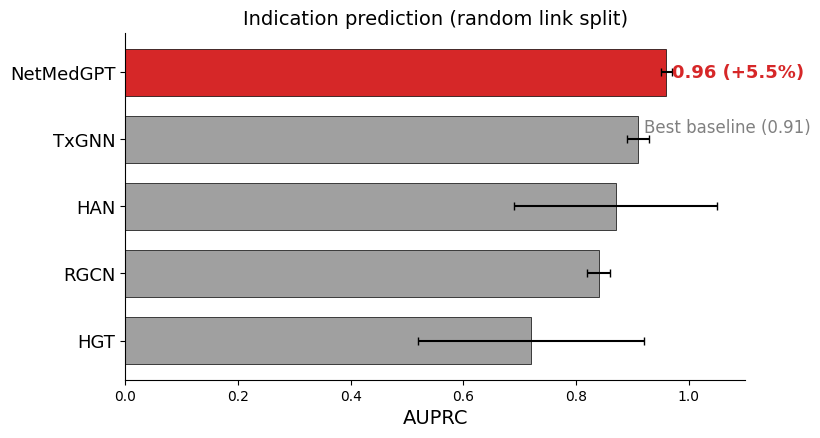

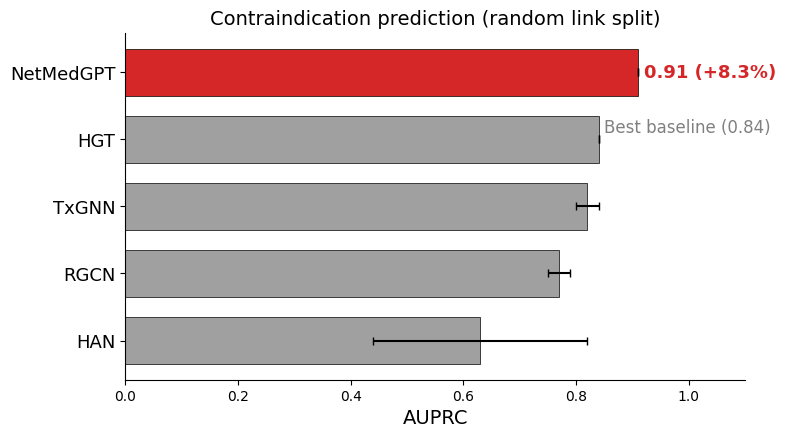

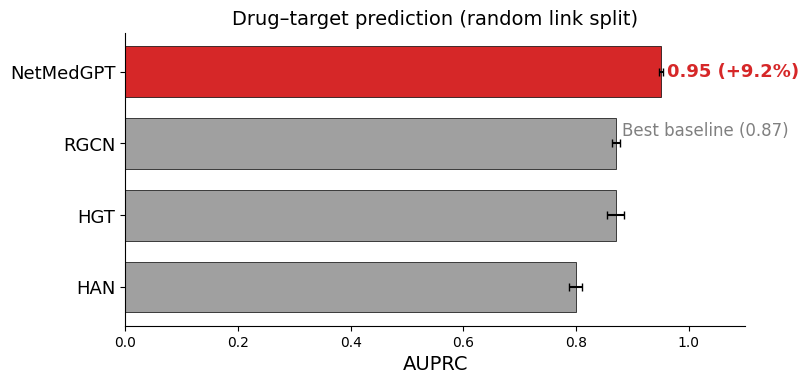

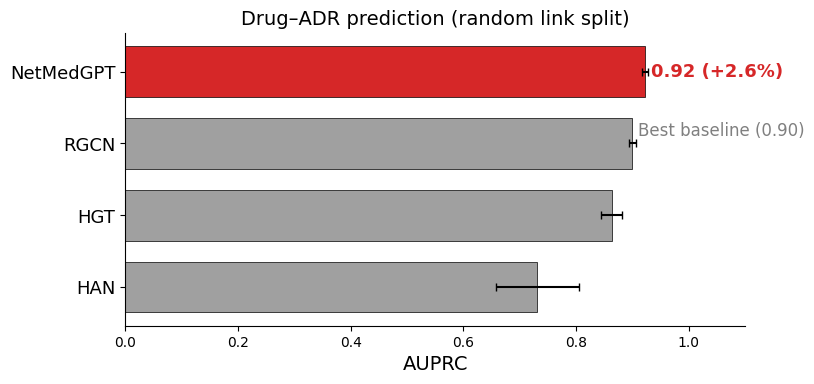

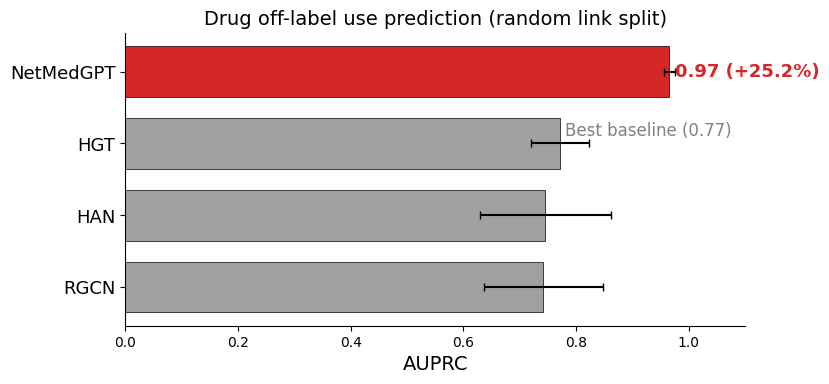

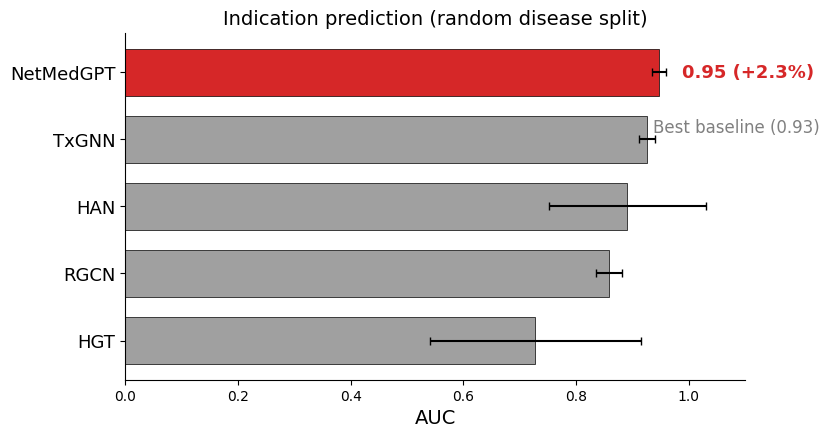

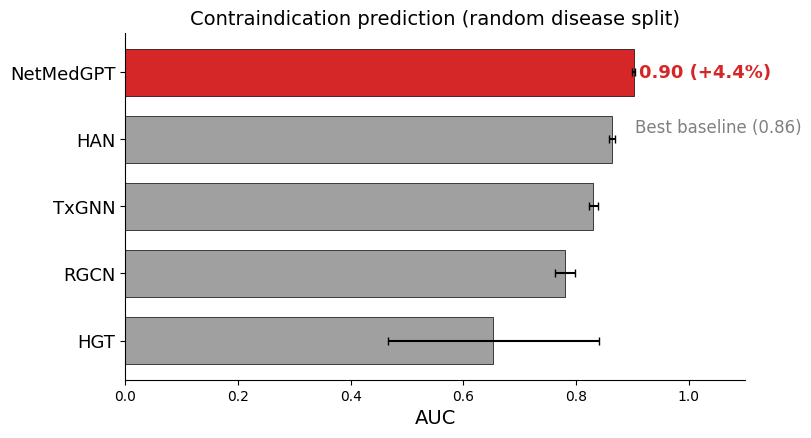

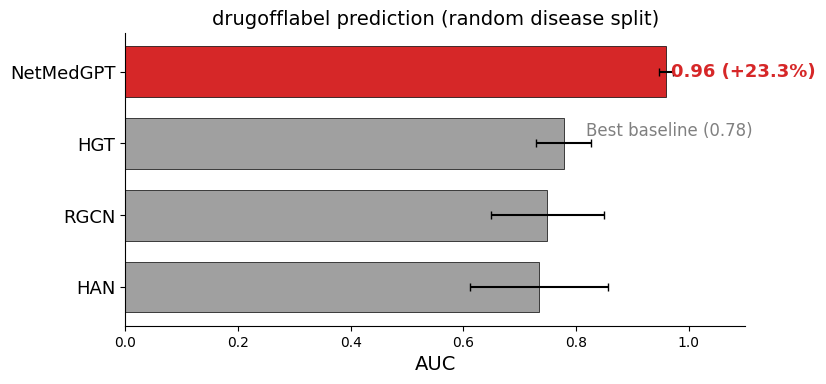

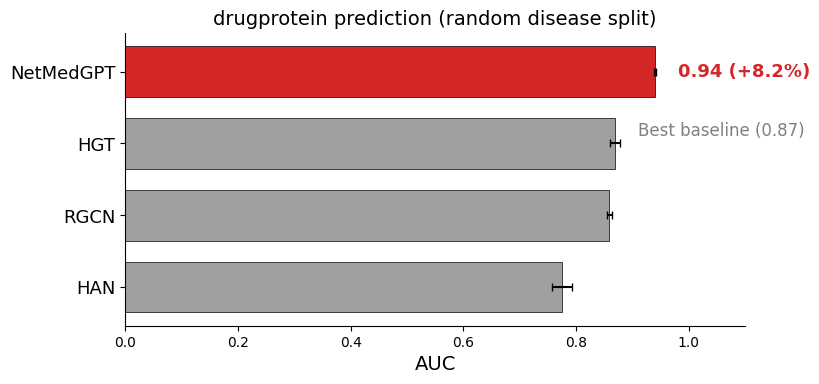

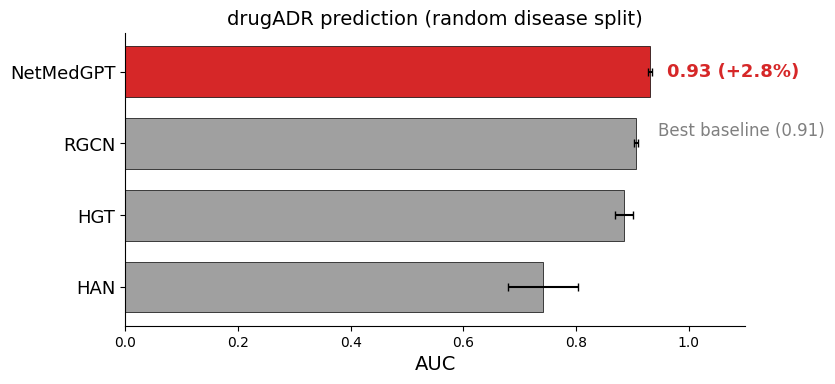

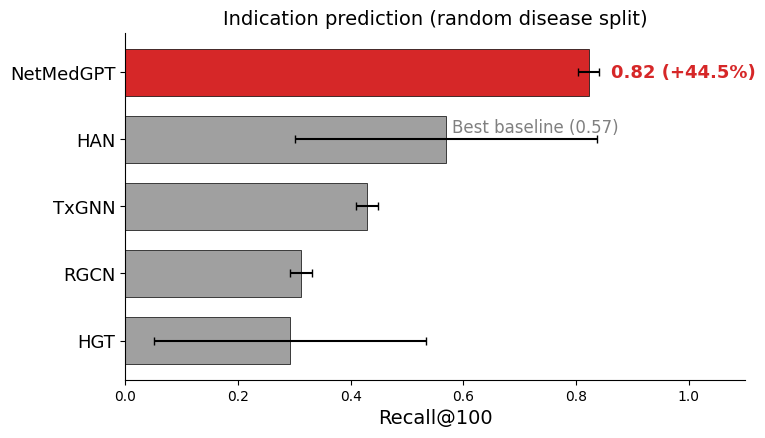

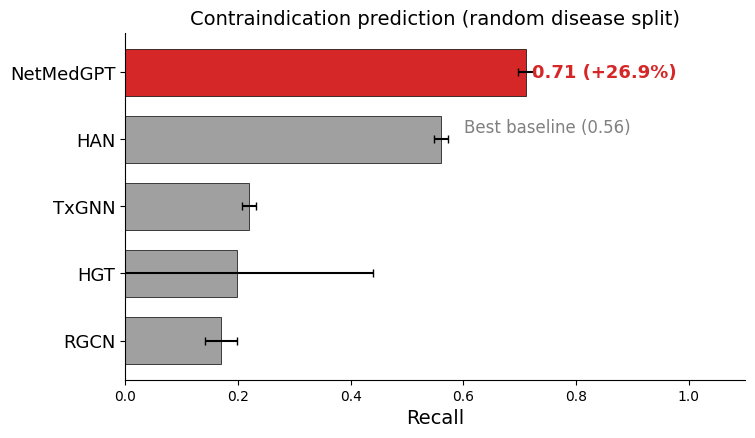

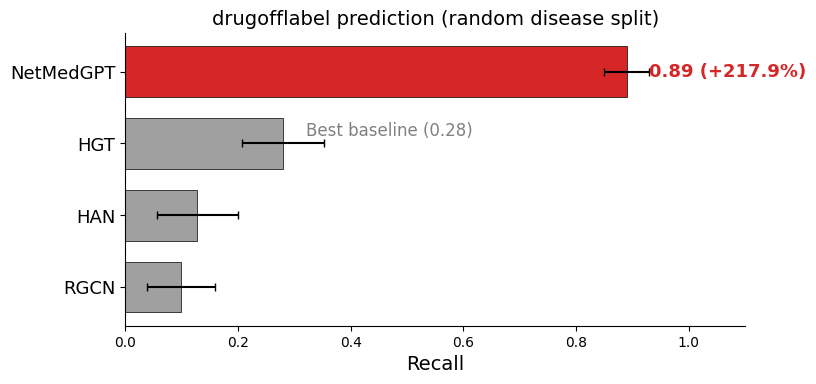

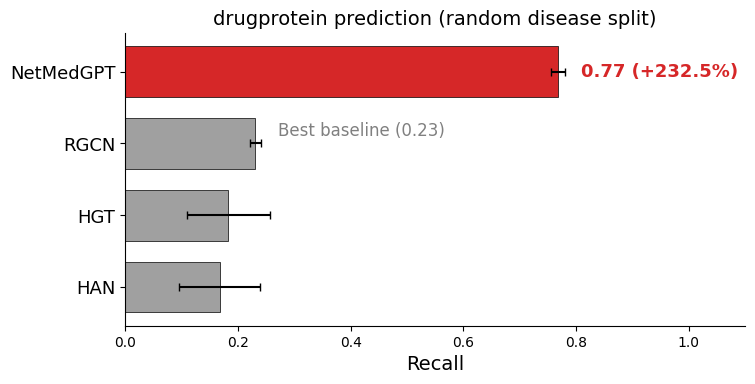

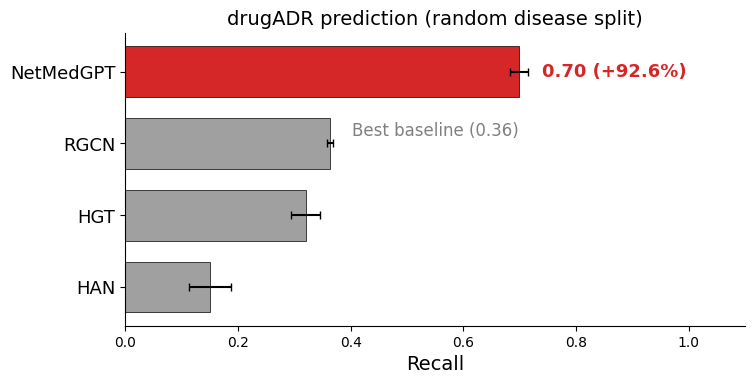

In [8]:
# random link split 
# NetMedGPT results
Lp_test_random = pd.read_csv(os.path.join(data_dir, "Lp_test_random_link_split.csv"))
recall_precision_random_link_split = pd.read_csv(os.path.join(data_dir, "recall_precision_random_link_split.csv"))

# Group by seed
grouped = Lp_test_random.groupby('seed')
indication_auprcs = grouped.nth(0)['auprc']
contraindication_auprcs = grouped.nth(1)['auprc']
offlabel_auprcs = grouped.nth(2)['auprc']
drugprotein_auprcs = grouped.nth(3)['auprc']
drugeffect_auprcs = grouped.nth(4)['auprc']

indication_aucs_netmedgpt = grouped.nth(0)['auc']
contraindication_aucs_netmedgpt = grouped.nth(1)['auc']
offlabel_aucs_netmedgpt = grouped.nth(2)['auc']
drugprotein_aucs_netmedgpt = grouped.nth(3)['auc']
drugeffect_aucs_netmedgpt = grouped.nth(4)['auc']

grouped_recall = recall_precision_random_link_split.groupby('seed')
indication_recall100_netmedgpt = grouped_recall.nth(0)['hit']
contraindication_recall100_netmedgpt = grouped_recall.nth(1)['hit']
offlabel_recall100_netmedgpt = grouped_recall.nth(2)['hit']
drugprotein_recall100_netmedgpt = grouped_recall.nth(3)['hit']
drugeffect_recall100_netmedgpt = grouped_recall.nth(4)['hit']

##### Compute mean and std of auprc
mean_indication_auprcs_netmedgpt = indication_auprcs.mean()
mean_contraindication_auprcs_netmedgpt = contraindication_auprcs.mean()
mean_offlabel_auprcs_netmedgpt = offlabel_auprcs.mean()
mean_drugprotein_auprcs_netmedgpt = drugprotein_auprcs.mean()
mean_drugeffect_auprcs_netmedgpt = drugeffect_auprcs.mean()


std_indication_auprcs_netmedgpt = indication_auprcs.std()
std_contraindication_auprcs_netmedgpt = contraindication_auprcs.std()
std_offlabel_auprcs_netmedgpt = offlabel_auprcs.std()
std_drugprotein_auprcs_netmedgpt = drugprotein_auprcs.std()
std_drugeffect_auprcs_netmedgpt = drugeffect_auprcs.std()


##### Compute mean and std of auc
mean_indication_aucs_netmedgpt = round(indication_aucs_netmedgpt.mean(), 3)
mean_contraindication_aucs_netmedgpt = round(contraindication_aucs_netmedgpt.mean(), 3)
mean_offlabel_aucs_netmedgpt = round(offlabel_aucs_netmedgpt.mean(), 3)
mean_drugprotein_aucs_netmedgpt = round(drugprotein_aucs_netmedgpt.mean(), 3)
mean_drugeffect_aucs_netmedgpt = round(drugeffect_aucs_netmedgpt.mean(), 3)

std_indication_aucs_netmedgpt = round(indication_aucs_netmedgpt.std(), 3)
std_contraindication_aucs_netmedgpt = round(contraindication_aucs_netmedgpt.std(), 3)
std_offlabel_aucs_netmedgpt = round(offlabel_aucs_netmedgpt.std(), 3)
std_drugprotein_aucs_netmedgpt = round(drugprotein_aucs_netmedgpt.std(), 3)
std_drugeffect_aucs_netmedgpt = round(drugeffect_aucs_netmedgpt.std(), 3)

##### Compute mean and std of recall@100
mean_indication_recall100_netmedgpt = round(indication_recall100_netmedgpt.mean(), 3)
mean_contraindication_recall100_netmedgpt = round(contraindication_recall100_netmedgpt.mean(), 3)
mean_offlabel_recall100_netmedgpt = round(offlabel_recall100_netmedgpt.mean(), 3)
mean_drugprotein_recall100_netmedgpt = round(drugprotein_recall100_netmedgpt.mean(), 3)
mean_drugeffect_recall100_netmedgpt = round(drugeffect_recall100_netmedgpt.mean(), 3)

std_indication_recall100_netmedgpt = round(indication_recall100_netmedgpt.std(), 3)
std_contraindication_recall100_netmedgpt = round(contraindication_recall100_netmedgpt.std(), 3)
std_offlabel_recall100_netmedgpt = round(offlabel_recall100_netmedgpt.std(), 3)
std_drugprotein_recall100_netmedgpt = round(drugprotein_recall100_netmedgpt.std(), 3)
std_drugeffect_recall100_netmedgpt = round(drugeffect_recall100_netmedgpt.std(), 3)

##################################################################################################################################
# AUPRC values for indication–random split

# AUPRC values for indication–random split
methods = ["HGT", "RGCN", "HAN", "TxGNN", "NetMedGPT"]
means = [0.72, 0.84, 0.87, 0.91, round(mean_indication_auprcs_netmedgpt, 2)]
stds = [0.2, 0.02, 0.18, 0.02, round(std_indication_auprcs_netmedgpt, 2)]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: NetMedGPT = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.01, + 0.9, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate NetMedGPT
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Indication prediction (random link split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

##################################################################################################################################
# AUPRC values for contraindication–random split
methods = ["HAN", "RGCN", "HGT", "TxGNN", "NetMedGPT"]
means = [0.63, 0.77, 0.84, 0.82, round(mean_contraindication_auprcs_netmedgpt, 2)]
stds = [0.19, 0.02, 0.00, 0.02, round(std_contraindication_auprcs_netmedgpt, 2)]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding NetMedGPT)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: NetMedGPT = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding
fig, ax = plt.subplots(figsize=(8, fig_height))

y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.01, + 0.9, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate NetMedGPT
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Contraindication prediction (random link split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

##################################################################################################################################
# AUPRC values for drug-protein–random split
drugprotein_auprcs = pd.DataFrame(
    [['RGCN', 'AUPRC', mean_drugprotein_auprc_RGCN, std_drugprotein_auprc_RGCN],
     ['HAN', 'AUPRC', mean_drugprotein_auprc_HAN, std_drugprotein_auprc_HAN],
     ['HGT', 'AUPRC', mean_drugprotein_auprc_HGT, std_drugprotein_auprc_HGT],
     ['NetMedGPT', 'AUPRC', mean_drugprotein_auprcs_netmedgpt, std_drugprotein_auprcs_netmedgpt]],
    columns=['method','Metric','mean','std']
)

methods = drugprotein_auprcs['method']
means = drugprotein_auprcs['mean']
stds = drugprotein_auprcs['std']

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding NetMedGPT)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: NetMedGPT = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot

# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)


# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.01, + 0.9, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate NetMedGPT
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Drug–target prediction (random link split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

##################################################################################################################
# AUPRC values for drug-ADR–random split
drugADR_auprcs = pd.DataFrame(
    [['RGCN', 'AUPRC', mean_drugADR_auprc_RGCN, std_drugADR_auprc_RGCN],
     ['HAN', 'AUPRC', mean_drugADR_auprc_HAN, std_drugADR_auprc_HAN],
     ['HGT', 'AUPRC', mean_drugADR_auprc_HGT, std_drugADR_auprc_HGT],
     ['NetMedGPT', 'AUPRC', mean_drugeffect_auprcs_netmedgpt, std_drugeffect_auprcs_netmedgpt]],
    columns=['method','Metric','mean','std']
)

methods = drugADR_auprcs['method']
means = drugADR_auprcs['mean']
stds = drugADR_auprcs['std']

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding NetMedGPT)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: NetMedGPT = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot

# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)


# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.01, + 0.9, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate NetMedGPT
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Drug–ADR prediction (random link split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
##################################################################################################################
# AUPRC values for drug-offlabel–random split
drugofflabel_auprcs = pd.DataFrame(
    [['RGCN', 'AUPRC', mean_drugofflabel_auprc_RGCN, std_drugofflabel_auprc_RGCN],
     ['HAN', 'AUPRC', mean_drugofflabel_auprc_HAN, std_drugofflabel_auprc_HAN],
     ['HGT', 'AUPRC', mean_drugofflabel_auprc_HGT, std_drugofflabel_auprc_HGT],
     ['NetMedGPT', 'AUPRC', mean_offlabel_auprcs_netmedgpt, std_offlabel_auprcs_netmedgpt]],
    columns=['method','Metric','mean','std']
)

methods = drugofflabel_auprcs['method']
means = drugofflabel_auprcs['mean']
stds = drugofflabel_auprcs['std']

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding NetMedGPT)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: NetMedGPT = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot

# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)


# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.01, + 0.9, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate NetMedGPT
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Drug off-label use prediction (random link split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)


##################################################################################################################
##################################################################################################################
# AUC values for indication–random split
indication_aucs_other = indication_res_random_split.loc[indication_res_random_split['Metric'] == 'AUROC',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_indication_aucs_netmedgpt, std_indication_aucs_netmedgpt]],
    columns=['method','Metric','mean','std']
)
indication_aucs = pd.concat([indication_aucs_other, new_row], ignore_index=True)

# AUC values for indication–random split
methods = indication_aucs['method'][[3,4,5,7,9]]
means = indication_aucs['mean'][[3,4,5,7,9]]
stds = indication_aucs['std'][[3,4,5,7,9]]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.01, +0.9, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

#####################
# AUC values for contraindication–random split
contraindication_aucs_other = contraindication_res_random_split.loc[contraindication_res_random_split['Metric'] == 'AUROC',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_contraindication_aucs_netmedgpt, std_contraindication_aucs_netmedgpt]],
    columns=['method','Metric','mean','std']
)
contraindication_aucs = pd.concat([contraindication_aucs_other, new_row], ignore_index=True)

# AUC values for contraindication–random split
methods = contraindication_aucs['method'][[3,4,5,7,9]]
means = contraindication_aucs['mean'][[3,4,5,7,9]]
stds = contraindication_aucs['std'][[3,4,5,7,9]]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, +0.9, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Contraindication prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

#####################
# AUC values for off-label–random split
drugofflabel_aucs = pd.DataFrame(
    [['RGCN', 'AUROC', mean_drugofflabel_auc_RGCN, std_drugofflabel_auc_RGCN],
     ['HAN', 'AUROC', mean_drugofflabel_auc_HAN, std_drugofflabel_auc_HAN],
     ['HGT', 'AUROC', mean_drugofflabel_auc_HGT, std_drugofflabel_auc_HGT],
     ['NetMedGPT', 'AUROC', mean_offlabel_aucs_netmedgpt, std_offlabel_aucs_netmedgpt]],
    columns=['method','Metric','mean','std']
)

# AUC values for drugofflabel–random split
methods = drugofflabel_aucs['method']
means = drugofflabel_aucs['mean']
stds = drugofflabel_aucs['std']

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, +0.9, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("drugofflabel prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

#####################
# AUC values for drug-protein–random split
drugprotein_aucs = pd.DataFrame(
    [['RGCN', 'AUROC', mean_drugprotein_auc_RGCN, std_drugprotein_auc_RGCN],
     ['HAN', 'AUROC', mean_drugprotein_auc_HAN, std_drugprotein_auc_HAN],
     ['HGT', 'AUROC', mean_drugprotein_auc_HGT, std_drugprotein_auc_HGT],
     ['NetMedGPT', 'AUROC', mean_drugprotein_aucs_netmedgpt, std_drugprotein_aucs_netmedgpt]],
    columns=['method','Metric','mean','std']
)

# AUC values for drugprotein–random split
methods = drugprotein_aucs['method']
means = drugprotein_aucs['mean']
stds = drugprotein_aucs['std']

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, +0.9, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("drugprotein prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

#####################
# AUC values for drug-effect–random split
drugADR_aucs = pd.DataFrame(
    [['RGCN', 'AUROC', mean_drugADR_auc_RGCN, std_drugADR_auc_RGCN],
     ['HAN', 'AUROC', mean_drugADR_auc_HAN, std_drugADR_auc_HAN],
     ['HGT', 'AUROC', mean_drugADR_auc_HGT, std_drugADR_auc_HGT],
     ['NetMedGPT', 'AUROC', mean_drugeffect_aucs_netmedgpt, std_drugeffect_aucs_netmedgpt]],
    columns=['method','Metric','mean','std']
)

# AUC values for drugADR–random split
methods = drugADR_aucs['method']
means = drugADR_aucs['mean']
stds = drugADR_aucs['std']

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, +0.9, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.03, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("drugADR prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

################################################################################################################
# Recall@100 values for indication–random split
indication_recall100_other = indication_res_random_split.loc[indication_res_random_split['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_indication_recall100_netmedgpt, std_indication_recall100_netmedgpt]],
    columns=['method','Metric','mean','std']
)

indication_recall100 = pd.concat([indication_recall100_other, new_row], ignore_index=True)

# Recall values for indication–random split
methods = indication_recall100['method'][[3,4,5,7,9]]
means = indication_recall100['mean'][[3,4,5,7,9]]
stds = indication_recall100['std'][[3,4,5,7,9]]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.01, +0.9, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("Recall@100", fontsize=14)
ax.set_title("Indication prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

#####################
# Recall@100 values for contraindication–random split
contraindication_recall100_other = contraindication_res_random_split.loc[contraindication_res_random_split['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_contraindication_recall100_netmedgpt, std_contraindication_recall100_netmedgpt]],
    columns=['method','Metric','mean','std']
)
contraindication_recall100 = pd.concat([contraindication_recall100_other, new_row], ignore_index=True)

# Recall values for contraindication–random split
methods = contraindication_recall100['method'][[3,4,5,7,9]]
means = contraindication_recall100['mean'][[3,4,5,7,9]]
stds = contraindication_recall100['std'][[3,4,5,7,9]]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, +0.9, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("Recall", fontsize=14)
ax.set_title("Contraindication prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

#####################
# Recall@100 values for drugofflabel–random split
drugofflabel_recall = pd.DataFrame(
    [['RGCN', 'AUROC', mean_drugofflabel_recall_RGCN, std_drugofflabel_recall_RGCN],
     ['HAN', 'AUROC', mean_drugofflabel_recall_HAN, std_drugofflabel_recall_HAN],
     ['HGT', 'AUROC', mean_drugofflabel_recall_HGT, std_drugofflabel_recall_HGT],
     ['NetMedGPT', 'AUROC', mean_offlabel_recall100_netmedgpt, std_offlabel_recall100_netmedgpt]],
    columns=['method','Metric','mean','std']
)

# Recall values for drugofflabel–random split
methods = drugofflabel_recall['method']
means = drugofflabel_recall['mean']
stds = drugofflabel_recall['std']

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))

y_pos = np.arange(len(methods))
bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, +0.9, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("Recall", fontsize=14)
ax.set_title("drugofflabel prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

#####################
# Recall@100 values for drugprotein–random split
drugprotein_recall = pd.DataFrame(
    [['RGCN', 'AUROC', mean_drugprotein_recall_RGCN, std_drugprotein_recall_RGCN],
     ['HAN', 'AUROC', mean_drugprotein_recall_HAN, std_drugofflabel_recall_HAN],
     ['HGT', 'AUROC', mean_drugprotein_recall_HGT, std_drugofflabel_recall_HGT],
     ['NetMedGPT', 'AUROC', mean_drugprotein_recall100_netmedgpt, std_drugprotein_recall100_netmedgpt]],
    columns=['method','Metric','mean','std']
)

# Recall values for drugprotein–random split
methods = drugprotein_recall['method']
means = drugprotein_recall['mean']
stds = drugprotein_recall['std']

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))

y_pos = np.arange(len(methods))
bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, +0.9, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("Recall", fontsize=14)
ax.set_title("drugprotein prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

#####################
# Recall@100 values for drugADR–random split
drugADR_recall = pd.DataFrame(
    [['RGCN', 'AUROC', mean_drugADR_recall_RGCN, std_drugADR_recall_RGCN],
     ['HAN', 'AUROC', mean_drugADR_recall_HAN, std_drugADR_recall_HAN],
     ['HGT', 'AUROC', mean_drugADR_recall_HGT, std_drugADR_recall_HGT],
     ['NetMedGPT', 'AUROC', mean_drugeffect_recall100_netmedgpt, std_drugeffect_recall100_netmedgpt]],
    columns=['method','Metric','mean','std']
)

# Recall values for drugADR–random split
methods = drugADR_recall['method']
means = drugADR_recall['mean']
stds = drugADR_recall['std']

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))

y_pos = np.arange(len(methods))
bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.04, +0.9, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("Recall", fontsize=14)
ax.set_title("drugADR prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)


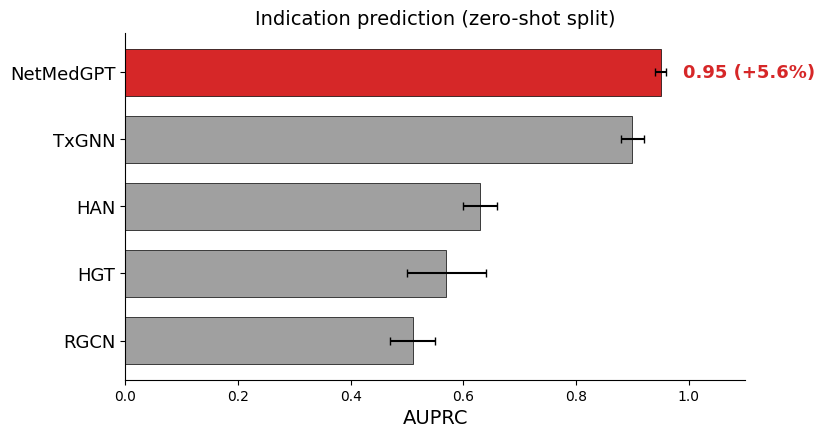

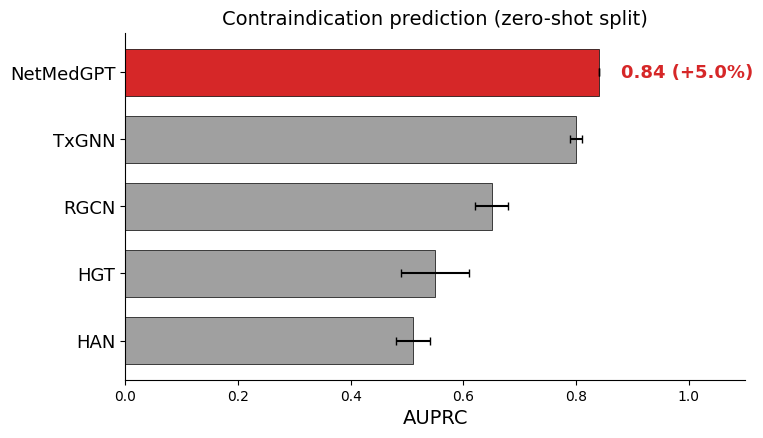

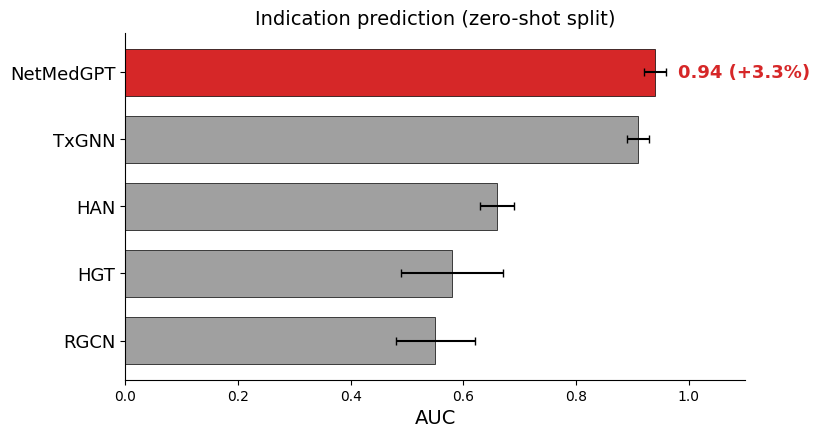

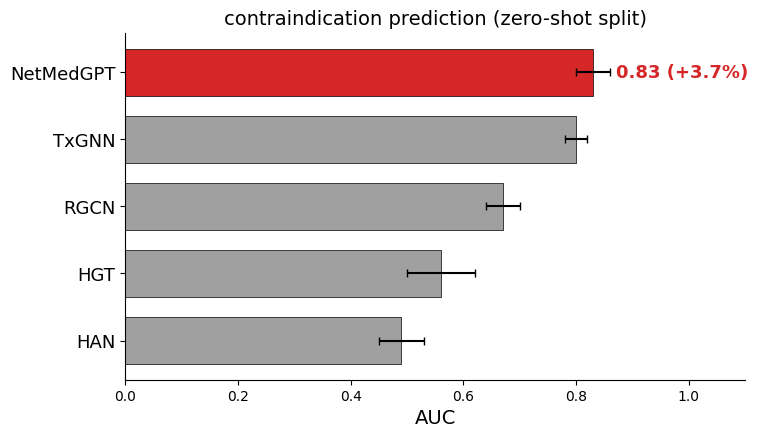

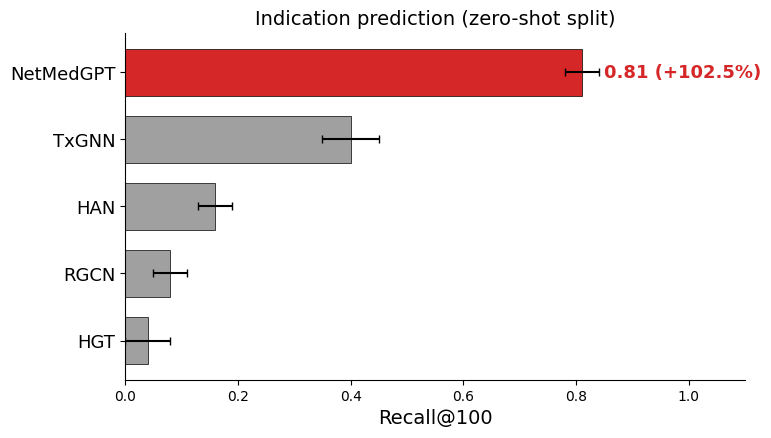

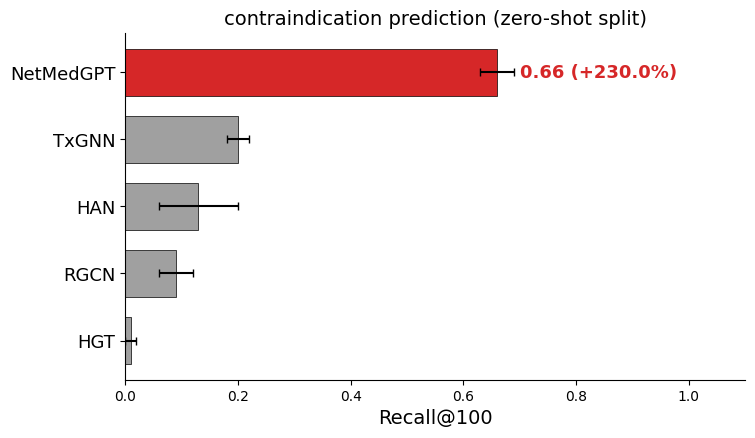

In [8]:
Lp_test_zeroshot = pd.read_csv(os.path.join(data_dir, "Lp_test_zeroshot.csv"))
recall_precision_zeroshot = pd.read_csv(os.path.join(data_dir, "recall_precision_zeroshot.csv"))

# Group by seed
grouped = Lp_test_zeroshot.groupby('seed')
grouped_recall = recall_precision_zeroshot.groupby('seed')

# Extract the first and second rows per seed
indication_auprcs_netmedgpt = grouped.nth(0)['auprc']
contraindication_auprcs_netmedgpt = grouped.nth(1)['auprc']

indication_aucs_netmedgpt = grouped.nth(0)['auc']
contraindication_aucs_netmedgpt = grouped.nth(1)['auc']

indication_recall100_netmedgpt = grouped_recall.nth(0)['hit']
contraindication_recall100_netmedgpt = grouped_recall.nth(1)['hit']

# # Compute their means
# # AUPRC
# mean_indication_auprcs_netmedgpt = round(indication_auprcs_netmedgpt.mean(), 2)
# mean_contraindication_auprcs_netmedgpt = round(contraindication_auprcs_netmedgpt.mean(), 2)
# std_indication_auprcs_netmedgpt = round(indication_auprcs_netmedgpt.std(), 2)
# std_contraindication_auprcs_netmedgpt = round(contraindication_auprcs_netmedgpt.std(),2)

# # AUC
# mean_indication_aucs_netmedgpt = round(indication_aucs_netmedgpt.mean(), 3)
# std_indication_aucs_netmedgpt = round(indication_aucs_netmedgpt.std(), 3)

######################################################################################################################
# AUPRC values for indication–zero shot
indication_auprcs_other = indication_res_zero_shot.loc[indication_res_zero_shot['Metric'] == 'AUPRC',:]

# NetMedGPT results
mean_indication_auprcs_netmedgpt = round(indication_auprcs_netmedgpt.mean(), 3)
std_indication_auprcs_netmedgpt = round(indication_auprcs_netmedgpt.std(), 3)

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUPRC', mean_indication_auprcs_netmedgpt, std_indication_auprcs_netmedgpt]],
    columns=['method','Metric','mean','std']
)

indication_auprcs = pd.concat([indication_auprcs_other, new_row], ignore_index=True)

methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_auprcs.loc[indication_auprcs['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_auprcs.loc[indication_auprcs['method'] == i, 'std'].item(), 2))

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding NetMedGPT)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: NetMedGPT = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)


# Annotate NetMedGPT
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

################
# AUPRC values for contraindication–zero-shot
contraindication_auprcs_other = contraindication_res_zero_shot.loc[contraindication_res_zero_shot['Metric'] == 'AUPRC',:]

# NetMedGPT results
mean_contraindication_auprcs_netmedgpt = round(contraindication_auprcs_netmedgpt.mean(), 3)
std_indication_auprcs_netmedgpt = round(contraindication_auprcs_netmedgpt.std(), 3)

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUPRC', mean_contraindication_auprcs_netmedgpt, std_contraindication_auprcs_netmedgpt]],
    columns=['method','Metric','mean','std']
)

contraindication_auprcs = pd.concat([contraindication_auprcs_other, new_row], ignore_index=True)

methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_auprcs.loc[contraindication_auprcs['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_auprcs.loc[contraindication_auprcs['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding NetMedGPT)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: NetMedGPT = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding
fig, ax = plt.subplots(figsize=(8, fig_height))

y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)


# Annotate NetMedGPT
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

######################################################################################################################
# AUC indication-zero shot
indication_aucs_other = indication_res_zero_shot.loc[indication_res_zero_shot['Metric'] == 'AUROC',:]

# NetMedGPT results
mean_indication_aucs_netmedgpt = round(indication_aucs_netmedgpt.mean(), 3)
std_indication_aucs_netmedgpt = round(indication_aucs_netmedgpt.std(), 3)

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_indication_aucs_netmedgpt, std_indication_aucs_netmedgpt]],
    columns=['method','Metric','mean','std']
)
indication_aucs = pd.concat([indication_aucs_other, new_row], ignore_index=True)

# plot AUC-indication
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_aucs.loc[indication_aucs['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_aucs.loc[indication_aucs['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)


##############################################################################
# AUC contraindication-zero shot
contraindication_aucs_other = contraindication_res_zero_shot.loc[contraindication_res_zero_shot['Metric'] == 'AUROC',:]

# NetMedGPT results
mean_contraindication_aucs = round(contraindication_aucs_netmedgpt.mean(), 3)
std_contraindication_aucs = round(contraindication_aucs_netmedgpt.std(), 3)

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_contraindication_aucs, std_contraindication_aucs]],
    columns=['method','Metric','mean','std']
)
contraindication_aucs = pd.concat([contraindication_aucs_other, new_row], ignore_index=True)


# plot AUC-contraindication
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []

for i in methods:
    means.append(round(contraindication_aucs.loc[contraindication_aucs['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_aucs.loc[contraindication_aucs['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)


######################################################################################################################
# Recall@100 indication-zero shot
indication_recall100_other = indication_res_zero_shot.loc[indication_res_zero_shot['Metric'] == 'Recall@100',:]
mean_indication_recall100_netmedgpt = round(indication_recall100_netmedgpt.mean(), 3)
std_indication_recall100_netmedgpt = round(indication_recall100_netmedgpt.std(), 3)

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_indication_recall100_netmedgpt, std_indication_recall100_netmedgpt]],
    columns=['method','Metric','mean','std']
)
indication_recall100 = pd.concat([indication_recall100_other, new_row], ignore_index=True)


methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_recall100.loc[indication_recall100['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_recall100.loc[indication_recall100['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("Recall@100", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

##############################
# contraindication
contraindication_recall100_other = contraindication_res_zero_shot.loc[contraindication_res_zero_shot['Metric'] == 'Recall@100',:]
mean_contraindication_recall100_netmedgpt = round(contraindication_recall100_netmedgpt.mean(), 3)
std_contraindication_recall100_netmedgpt = round(contraindication_recall100_netmedgpt.std(), 3)

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_contraindication_recall100_netmedgpt, std_contraindication_recall100_netmedgpt]],
    columns=['method','Metric','mean','std']
)
contraindication_recall100 = pd.concat([contraindication_recall100_other, new_row], ignore_index=True)

# plot Recall@100-contraindication
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_recall100.loc[contraindication_recall100['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_recall100.loc[contraindication_recall100['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)


for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("Recall@100", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
